### Import data and explore

The data contains 9568 data points depicting the enery output of a power plant and the ambient conditions at the power plant, over the course of six years.

Power is generated by a combination of steam and gas turbines.

- AT - Temperature
- AP - Ambient Pressure
- RH - Relative Humidity
- V - Exhaust Vaccum
- PE - Power output

Data source and citation: Tfekci, P. & Kaya, H. (2014). Combined Cycle Power Plant [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5002N.

In [43]:
import pandas
import matplotlib.pyplot as plot
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [34]:
data = pandas.read_excel("../data/Folds5x2_pp.xlsx")

data

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90
...,...,...,...,...,...
9563,16.65,49.69,1014.01,91.00,460.03
9564,13.19,39.18,1023.67,66.78,469.62
9565,31.32,74.33,1012.92,36.48,429.57
9566,24.48,69.45,1013.86,62.39,435.74


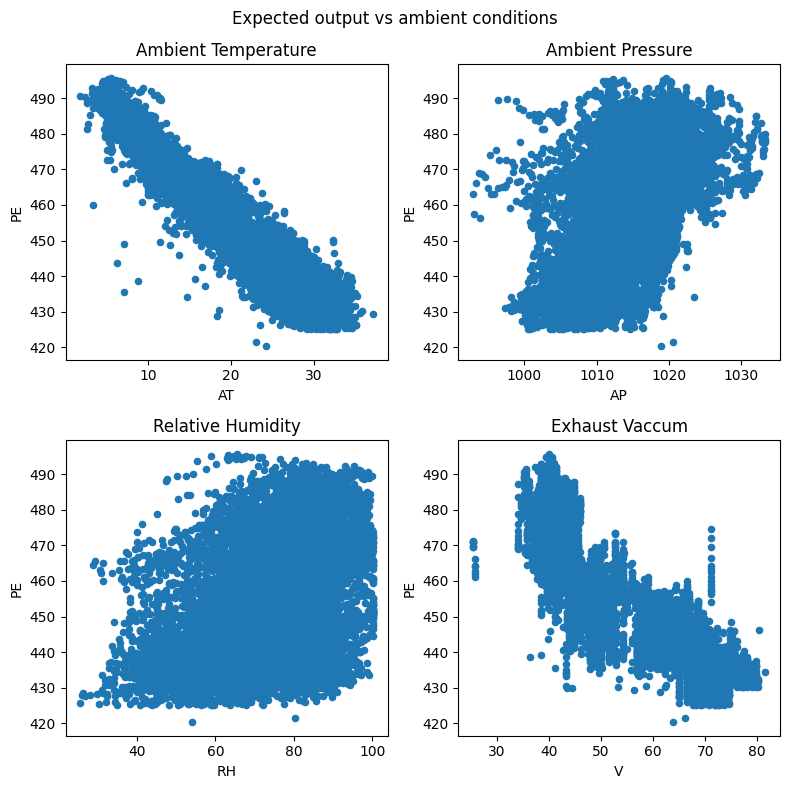

In [35]:
overall_figure, axes = plot.subplots(2,2, figsize=(8,8))

overall_figure.suptitle("Expected output vs ambient conditions")

axes[0][0].set_title("Ambient Temperature")
data.plot(kind="scatter", x="AT", y="PE", ax=axes[0][0])

axes[0][1].set_title("Ambient Pressure")
data.plot(kind="scatter", x="AP", y="PE", ax=axes[0][1])

axes[1][0].set_title("Relative Humidity")
data.plot(kind="scatter", x="RH", y="PE", ax=axes[1][0])

axes[1][1].set_title("Exhaust Vaccum")
data.plot(kind="scatter", x="V", y="PE", ax=axes[1][1])

overall_figure.tight_layout()

Visually the following trends may be observed:
- There seems to be a decrease in the Power output with increase in ambient temperature (AT) and Exhaust Vaccum (V).
- The power output seems to increase with increase in ambient pressure (AP)
- The upper limit on power output seems to increase with increase in relative humidity



In [36]:
pandas.concat([
        data.mean(),
        data.median(),
        data.max() - data.min(),
        data.quantile(0.25),
        data.quantile(0.75)
    ],
    axis=1,
    keys=["Mean", "Median", "Range", "1st Quartile", "3rd Quartile"])

,Mean,Median,Range,1st Quartile,3rd Quartile
AT,19.651231,20.345,35.30,13.5100,25.72
V,54.305804,52.080,56.20,41.7400,66.54
AP,1013.259078,1012.940,40.41,1009.1000,1017.26
RH,73.308978,74.975,74.60,63.3275,84.83
PE,454.365009,451.550,75.50,439.7500,468.43


### Linear Regression on individual variables

In [49]:
# Create train and test data
for col in data.columns:
    X_train, X_test, y_train, y_test = train_test_split(data[col], data['PE'], test_size=0.3)
    # print(col)
    predictor = LinearRegression().fit(X_train, y_train)
    # predictions = predictor.predict(X_test)
    print(f"{col}: {predictor.score(X_test, y_test)}")
    

ValueError: Expected a 2-dimensional container but got <class 'pandas.core.series.Series'> instead. Pass a DataFrame containing a single row (i.e. single sample) or a single column (i.e. single feature) instead.